<a href="https://colab.research.google.com/github/ludmila-sla/detec-o-de-autoria/blob/main/redes_neurais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

caminho_base = "/content/drive/MyDrive/redes neurais artigo/"

with open(caminho_base + "poe.txt", "r", encoding="utf-8") as f:
    poe = f.read()
with open(caminho_base + "poe2.txt", "r", encoding="utf-8") as f:
    poe2 = f.read()

with open(caminho_base + "arthur1.txt", "r", encoding="utf-8") as f:
    doyle1 = f.read()

with open(caminho_base + "arthur2.txt", "r", encoding="utf-8") as f:
    doyle2 = f.read()

with open(caminho_base + "mary.txt", "r", encoding="utf-8") as f:
    mary = f.read()
with open(caminho_base + "mary2.txt", "r", encoding="utf-8") as f:
    mary2 = f.read()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import re

def cortar_inicio(texto, marcador):
    idx = texto.find(marcador)
    if idx != -1:
        return texto[idx:]
    return texto


def limpar_texto(texto):
    texto = texto.lower()

    fim = texto.find("end of the project gutenberg ebook")
    if fim != -1:
      texto = texto[:fim]

    texto = re.sub(r'\d+', '', texto)
    texto = re.sub(r'[^\w\s.,;:!?-]', '', texto)
    texto = re.sub(r'\s+', ' ', texto)

    return texto.strip()

In [ ]:
def dividir_em_blocos(texto, tamanho=300):
    palavras = texto.split()
    blocos = []

    for i in range(0, len(palavras), tamanho):
        bloco = palavras[i:i+tamanho]
        if len(bloco) == tamanho:
            blocos.append(" ".join(bloco))

    return blocos

In [ ]:


poe = cortar_inicio(poe, "THE UNPARALLELED ADVENTURES OF ONE HANS PFAAL (*1)")
poe2 = cortar_inicio(poe2, "At Paris, just after dark")
doyle1 = cortar_inicio(doyle1, "A SCANDAL IN BOHEMIA")
doyle2 = cortar_inicio(doyle2, "THE ADVENTURE OF THE EMPTY HOUSE")
mary = cortar_inicio(mary, "Letter 1")
mary2 = cortar_inicio(mary2, "And near Albano’s scarce")


poe_train = limpar_texto(poe)
poe_test = limpar_texto(poe2)
doyle_train = limpar_texto(doyle1)
doyle_test = limpar_texto(doyle2)
mary_train = limpar_texto(mary)
mary_test = limpar_texto(mary2)

blocos_poe_train = dividir_em_blocos(poe_train)
blocos_poe_test = dividir_em_blocos(poe_test)
blocos_doyle_train = dividir_em_blocos(doyle_train)
blocos_doyle_test = dividir_em_blocos(doyle_test)
blocos_mary_train = dividir_em_blocos(mary_train)
blocos_mary_test = dividir_em_blocos(mary_test)

print(len(blocos_poe_train), len(blocos_doyle_train), len(blocos_mary_train))



272 347 249


In [ ]:
dados_train = []
labels_train = []
dados_test = []
labels_test = []

for bloco in blocos_poe_train:
    dados_train.append(bloco)
    labels_train.append("poe")

for bloco in blocos_doyle_train:
    dados_train.append(bloco)
    labels_train.append("doyle")

for bloco in blocos_mary_train:
    dados_train.append(bloco)
    labels_train.append("mary")

for bloco in blocos_mary_test:
    dados_test.append(bloco)
    labels_test.append("mary")


for bloco in blocos_poe_test:
    dados_test.append(bloco)
    labels_test.append("poe")

for bloco in blocos_doyle_test:
    dados_test.append(bloco)
    labels_test.append("doyle")


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(dados_train)
X_test = vectorizer.transform(dados_test)

y_train = labels_train
y_test = labels_test

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

modelo = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=42
)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)


print("Acurácia:", accuracy_score(y_test, y_pred))

Acurácia: 0.9258589511754068


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       doyle       0.88      0.99      0.94       373
        mary       0.94      0.91      0.93       417
         poe       0.96      0.87      0.91       316

    accuracy                           0.93      1106
   macro avg       0.93      0.92      0.92      1106
weighted avg       0.93      0.93      0.93      1106



In [ ]:
novo = ["I am a journalist on the staff of the Daily Gazette. My name is Edward Malone. I propose to tell here the story of the most remarkable adventure in which I ever found myself engaged."]
novo_vec = vectorizer.transform(novo)
print(modelo.predict(novo_vec))

['poe']


probabilidade autoral

In [ ]:
def prever_autor_mlp(texto, vectorizer, modelo):
    texto_limpo = limpar_texto(texto)
    texto_vec = vectorizer.transform([texto_limpo])

    pred = modelo.predict(texto_vec)[0]
    probs = modelo.predict_proba(texto_vec)[0]

    return pred, probs

texto = "It was a dark and silent night..."

autor = prever_autor_mlp(texto, vectorizer, modelo)
print("Autor previsto:", autor)
autor, probs = prever_autor_mlp(texto, vectorizer, modelo)

print("Autor previsto:", autor)
print("Probabilidades:", probs)

Autor previsto: (np.str_('doyle'), array([0.58324413, 0.30290046, 0.11385541]))
Autor previsto: doyle
Probabilidades: [0.58324413 0.30290046 0.11385541]


modelo lstm

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(dados_train)

X_train_seq = tokenizer.texts_to_sequences(dados_train)
X_test_seq = tokenizer.texts_to_sequences(dados_test)

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(labels_train)
y_test_enc = encoder.transform(labels_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

modelo = Sequential()

modelo.add(Embedding(input_dim=5000, output_dim=128, input_length=max_len))
modelo.add(LSTM(64))
modelo.add(Dense(3, activation='softmax'))

modelo.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
modelo.fit(
    X_train_pad,
    y_train_enc,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_pad, y_test_enc)
)

loss, acc = modelo.evaluate(X_test_pad, y_test_enc)
print("Acurácia:", acc)

Epoch 1/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.3871 - loss: 1.0787 - val_accuracy: 0.3373 - val_loss: 1.3002
Epoch 2/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 0.6751 - loss: 0.7420 - val_accuracy: 0.6826 - val_loss: 0.8088
Epoch 3/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.9101 - loss: 0.3374 - val_accuracy: 0.6881 - val_loss: 0.7231
Epoch 4/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.9689 - loss: 0.1382 - val_accuracy: 0.7830 - val_loss: 0.5737
Epoch 5/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.9919 - loss: 0.0580 - val_accuracy: 0.7098 - val_loss: 1.2942
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7098 - loss: 1.2942
Acurácia: 0.7097648978233337


prever autor

In [ ]:
def prever_autor_lstm(texto, tokenizer, modelo, max_len, encoder):
    texto_limpo = limpar_texto(texto)

    seq = tokenizer.texts_to_sequences([texto_limpo])
    pad = pad_sequences(seq, maxlen=max_len)

    pred = modelo.predict(pad, verbose=0)[0]
    classe = pred.argmax()

    autor = encoder.inverse_transform([classe])[0]

    return autor, pred

autor, probs = prever_autor_lstm(texto, tokenizer, modelo, max_len, encoder)

print("Autor previsto:", autor)
print("Probabilidades:", probs)

Autor previsto: poe
Probabilidades: [0.06037857 0.02874823 0.9108732 ]


testando varias quantidades de palavras


In [ ]:
def rodar_experimento_completo(tamanho_bloco):
    print(f"\n=== Testando com {tamanho_bloco} palavras ===")

    blocos_poe_train = dividir_em_blocos(poe_train, tamanho_bloco)
    blocos_poe_test = dividir_em_blocos(poe_test, tamanho_bloco)

    blocos_doyle_train = dividir_em_blocos(doyle_train, tamanho_bloco)
    blocos_doyle_test = dividir_em_blocos(doyle_test, tamanho_bloco)

    blocos_mary_train = dividir_em_blocos(mary_train, tamanho_bloco)
    blocos_mary_test = dividir_em_blocos(mary_test, tamanho_bloco)

    dados_train, labels_train = [], []
    dados_test, labels_test = [], []

    for bloco in blocos_poe_train:
        dados_train.append(bloco)
        labels_train.append("poe")

    for bloco in blocos_doyle_train:
        dados_train.append(bloco)
        labels_train.append("doyle")

    for bloco in blocos_mary_train:
        dados_train.append(bloco)
        labels_train.append("mary")

    for bloco in blocos_poe_test:
        dados_test.append(bloco)
        labels_test.append("poe")

    for bloco in blocos_doyle_test:
        dados_test.append(bloco)
        labels_test.append("doyle")

    for bloco in blocos_mary_test:
        dados_test.append(bloco)
        labels_test.append("mary")

    # ======================
    # 🔹 MLP (TF-IDF)
    # ======================
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.neural_network import MLPClassifier
    from sklearn.metrics import accuracy_score

    vectorizer = TfidfVectorizer(max_features=5000)

    X_train = vectorizer.fit_transform(dados_train)
    X_test = vectorizer.transform(dados_test)

    mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
    mlp.fit(X_train, labels_train)

    y_pred = mlp.predict(X_test)
    acc_mlp = accuracy_score(labels_test, y_pred)

    print("MLP Acurácia:", acc_mlp)

    # ======================
    # 🔹 LSTM
    # ======================
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, LSTM, Dense
    from sklearn.preprocessing import LabelEncoder

    tokenizer = Tokenizer(num_words=5000)
    tokenizer.fit_on_texts(dados_train)

    X_train_seq = tokenizer.texts_to_sequences(dados_train)
    X_test_seq = tokenizer.texts_to_sequences(dados_test)

    max_len = 100

    X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
    X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

    encoder = LabelEncoder()
    y_train_enc = encoder.fit_transform(labels_train)
    y_test_enc = encoder.transform(labels_test)

    lstm = Sequential()
    lstm.add(Embedding(input_dim=5000, output_dim=128, input_length=max_len))
    lstm.add(LSTM(64))
    lstm.add(Dense(3, activation='softmax'))

    lstm.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    lstm.fit(
        X_train_pad,
        y_train_enc,
        epochs=5,
        batch_size=32,
        verbose=0,
        validation_data=(X_test_pad, y_test_enc)
    )

    loss, acc_lstm = lstm.evaluate(X_test_pad, y_test_enc, verbose=0)

    print("LSTM Acurácia:", acc_lstm)

    return acc_mlp, acc_lstm

In [ ]:
resultados_mlp = {}
resultados_lstm = {}

for tamanho in [100, 200, 300]:
    acc_mlp, acc_lstm = rodar_experimento_completo(tamanho)
    resultados_mlp[tamanho] = acc_mlp
    resultados_lstm[tamanho] = acc_lstm

print("\nMLP:", resultados_mlp)
print("LSTM:", resultados_lstm)


=== Testando com 100 palavras ===
MLP Acurácia: 0.8635131063573366


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM Acurácia: 0.7722205519676208

=== Testando com 200 palavras ===
MLP Acurácia: 0.9216395418927065


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM Acurácia: 0.8173598647117615

=== Testando com 300 palavras ===
MLP Acurácia: 0.9258589511754068


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM Acurácia: 0.6980108618736267

MLP: {100: 0.8635131063573366, 200: 0.9216395418927065, 300: 0.9258589511754068}
LSTM: {100: 0.7722205519676208, 200: 0.8173598647117615, 300: 0.6980108618736267}


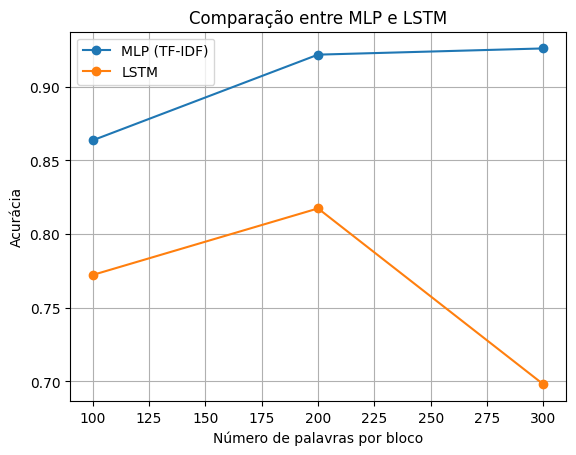

In [ ]:
import matplotlib.pyplot as plt

tamanhos = [100, 200, 300]

mlp_vals = [resultados_mlp[t] for t in tamanhos]
lstm_vals = [resultados_lstm[t] for t in tamanhos]

plt.figure()

plt.plot(tamanhos, mlp_vals, marker='o', label='MLP (TF-IDF)')
plt.plot(tamanhos, lstm_vals, marker='o', label='LSTM')

plt.xlabel("Número de palavras por bloco")
plt.ylabel("Acurácia")
plt.title("Comparação entre MLP e LSTM")

plt.legend()
plt.grid()

plt.show()

In [ ]:
pred_probs = modelo.predict(X_test_pad)
y_pred = pred_probs.argmax(axis=1)

y_pred_labels = encoder.inverse_transform(y_pred)


print(classification_report(labels_test, y_pred_labels))



35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
              precision    recall  f1-score   support

       doyle       0.63      0.97      0.77       373
        mary       0.91      0.50      0.65       417
         poe       0.71      0.67      0.69       316

    accuracy                           0.71      1106
   macro avg       0.75      0.72      0.70      1106
weighted avg       0.76      0.71      0.70      1106

